<a href="https://colab.research.google.com/github/miguelmorandini/am-t4-s1a2026/blob/main/MultiNeuralCensus0512.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline Naive Bayes | Digest GaussianNB [Fase 1 - census_data]

## Importar dados do Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Bibliotecas de Python

In [3]:
!pip -q install plotly        #instala biblioteca para gráficos interativos (zoom, hover, dashboards)
!pip -q install yellowbrick   #instala visualizações para modelos de ML (curvas, clusters, métricas)

In [4]:
import pandas as pd               #manipulação de dados (tabelas/DataFrame)
import numpy as np                #operações matemáticas e arrays
import seaborn as sns             #gráficos estatísticos mais simples
import matplotlib.pyplot as plt   #criação de gráficos básicos
import plotly.express as px       #gráficos interativos

## Carregar Digest de base_census

In [5]:
import pickle

In [6]:
with open('/content/drive/MyDrive/DSM/5º Semestre - 2026/aprendizagem-de-maquina/amt4/census.pkt', 'rb') as f:
  X_census_treinamento, Y_census_treinamento, X_census_teste, Y_census_teste = pickle.load(f)

In [7]:
X_census_treinamento.shape, X_census_teste.shape

((27676, 108), (4885, 108))

In [8]:
Y_census_treinamento.shape, Y_census_teste.shape

((27676,), (4885,))

In [9]:
# Importa o classificador Naive Bayes com distribuição Gaussiana
from sklearn.naive_bayes import GaussianNB

In [10]:
# Cria uma instância do classificador Gaussian Naive Bayes
naive_census_data = GaussianNB()

# Treina o modelo com os dados de treinamento
# fit ajusta o modelo com base nas features (X) e nos rótulos (Y)
naive_census_data.fit(X_census_treinamento, Y_census_treinamento)

GaussianNB()

## Criando Base Previsora

previsao_censuso

In [11]:
# Realiza previsões utilizando o modelo treinado
# predict recebe os dados de teste (X) e retorna os rótulos previstos
census_predict = naive_census_data.predict(X_census_teste)

In [12]:
# Variável que armazena as previsões geradas pelo modelo
# Contém os rótulos previstos para os dados de teste
census_predict

array([' >50K', ' >50K', ' >50K', ..., ' <=50K', ' >50K', ' >50K'],
      dtype='<U6')

In [13]:
# Variável que contém os rótulos reais (valores verdadeiros) do conjunto de teste
# Representa a saída correta esperada para cada registro de X_census_teste
Y_census_teste

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' <=50K'],
      dtype=object)

In [14]:
# Importa métricas para avaliação de modelos de classificação
# accuracy_score calcula a proporção de acertos do modelo
# confusion_matrix gera a matriz de confusão (comparação entre valores reais e previstos)
# classification_report apresenta métricas como precisão, recall e f1-score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [15]:
# Calcula a acurácia do modelo comparando valores reais com previsões
accuracy_score(Y_census_teste, census_predict)

0.4767656090071648

In [16]:
# Gera a matriz de confusão comparando valores reais e previstos
confusion_matrix(Y_census_teste, census_predict)

array([[1172, 2521],
       [  35, 1157]])

In [17]:
# Importa a classe ConfusionMatrix da biblioteca Yellowbrick
# Usada para visualizar graficamente a matriz de confusão
from yellowbrick.classifier import ConfusionMatrix

0.4767656090071648

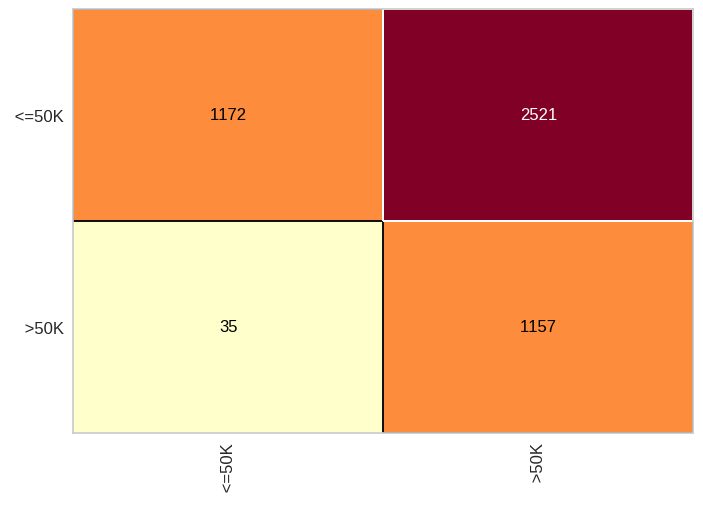

In [18]:
# Cria o objeto de visualização da matriz de confusão usando o modelo treinado
cm_census = ConfusionMatrix(naive_census_data)

# Ajusta o visualizador com os dados de treinamento
# fit associa o modelo aos dados
cm_census.fit(X_census_treinamento, Y_census_treinamento)

# Avalia o modelo com os dados de teste
# score calcula as previsões e prepara a matriz de confusão para visualização
cm_census.score(X_census_teste, Y_census_teste)

# Pipeline Arvore de Decisão | Treemap Base [Fase 2 - census_data]

In [19]:
# Importa o algoritmo Decision Tree (Árvore de Decisão)
# da biblioteca scikit-learn
from sklearn.tree import DecisionTreeClassifier

In [20]:
# Cria o modelo de Árvore de Decisão
# Usa entropia para escolher as melhores divisões da árvore
 # Mantém os resultados iguais em toda execução
arvore_census_data = DecisionTreeClassifier(criterion='entropy', random_state=0)

# Treina a árvore com os dados de treinamento
# Variáveis de entrada (idade, renda, dívida etc.)
# Respostas corretas (pagou ou não pagou, por exemplo)
arvore_census_data.fit(X_census_treinamento, Y_census_treinamento)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [21]:
DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='entropy',
                       max_depth=None, max_features=None, max_leaf_nodes=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0,
                       random_state=0, splitter='best')

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [22]:
previsoes_arvore = arvore_census_data.predict(X_census_teste)

In [23]:
previsoes_arvore

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype=object)

In [24]:
Y_census_teste

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' <=50K'],
      dtype=object)

## Pipeline Medições Harmonicas | Treemap Base [Fase 3 - census_data]

In [25]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [26]:
accuracy_score(Y_census_teste, previsoes_arvore)

0.8104401228249745

In [27]:
from yellowbrick.classifier import ConfusionMatrix

/usr/local/lib/python3.12/dist-packages/yellowbrick/classifier/base.py:232: YellowbrickWarning: could not determine class_counts_ from previously fitted classifier
  warnings.warn(


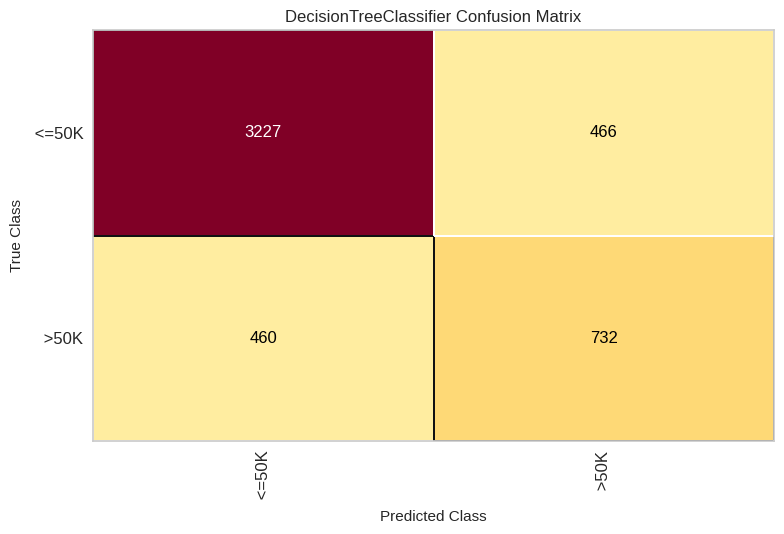

<Axes: title={'center': 'DecisionTreeClassifier Confusion Matrix'}, xlabel='Predicted Class', ylabel='True Class'>

In [28]:
# Cria o visualizador da matriz
confusion_matrix = ConfusionMatrix(arvore_census_data)

# Faz previsões no conjunto de teste
confusion_matrix.score(X_census_teste, Y_census_teste)

# Exibe o gráfico colorido
confusion_matrix.show()

In [29]:
print(classification_report(Y_census_teste, previsoes_arvore, target_names=['adimplentes', 'inadimplentes']))

               precision    recall  f1-score   support

  adimplentes       0.88      0.87      0.87      3693
inadimplentes       0.61      0.61      0.61      1192

     accuracy                           0.81      4885
    macro avg       0.74      0.74      0.74      4885
 weighted avg       0.81      0.81      0.81      4885

